<a href="https://colab.research.google.com/github/am-3/IB9AU-2026/blob/main/Task9_%22DateDrift%22_Amortization_Audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 9: "Date Drift" Amortization Audit
Atharva M
___
## Objective
This notebook performs a detailed audit of a small business loan amortization schedule, specifically addressing the common pitfalls of "calendar math" in financial calculations. The primary goal is to accurately calculate principal and interest payments for irregular payment dates, including those impacted by leap years, to determine the precise ending principal balance and total interest paid. This directly addresses the challenge of Large Language Models (LLMs) hallucinating simplified amortization schedules that often disregard these real-world complexities.
___
## Tech Stack
*   **Python**: Core programming language.
*   **`datetime` module**: For precise date calculations and handling.
*   **`calendar` module**: For leap year determination.
*   **`matplotlib`**: For data visualization.
*   **`seaborn`**: For enhanced statistical data visualization.
*   **`pandas`**: For data manipulation and structuring for plotting.
___
## Methodology
The audit employs a period-by-period amortization approach. Key steps include:
1.  **Calendar Verification**: Accurately determining the exact number of days between payment dates, including accounting for leap years. This is crucial for precise daily interest accrual.
2.  **Daily Interest Calculation**: Interest is calculated daily based on the current outstanding principal balance, the annual interest rate, and the exact number of days elapsed for each period. The formula for daily interest is: $Interest = Principal \times \frac{Annual Rate}{365} \times Days Elapsed$.
3.  **Payment Allocation**: Each payment is first applied to accrued interest for the period, with the remainder reducing the principal balance.
4.  **Iterative Amortization**: The process is iterated for each payment, updating the principal balance for the subsequent period.
5.  **Results Quantification & Visualization**: The final principal balance and total interest paid are presented both numerically and visually, providing a verifiable audit outcome.
___

In [ ]:
from datetime import date

# --- Loan Details ---
initial_principal = 100000.00
annual_interest_rate = 0.12 # 12% annual interest rate

# --- Payment Details ---
# Specific payment dates to audit
payment_1_date = date(2024, 1, 31)
payment_2_date = date(2024, 2, 29) # Note: 2024 is a leap year
payment_3_date = date(2024, 3, 31)

payment_amount = 5000.00 # Consistent payment amount for each period

start_date = date(2024, 1, 1) # Loan start date

# Display initial loan parameters for clarity
print(f"Initial Loan Principal: ${initial_principal:,.2f}")
print(f"Annual Interest Rate: {annual_interest_rate:.2%}")
print(f"Loan Start Date: {start_date}")

Initial Loan Principal: $100,000.00
Annual Interest Rate: 12.00%
Loan Start Date: 2024-01-01


### Step 1: Calendar Verification (Crucial)

In [ ]:
import calendar

# Verify if the loan's start year is a leap year. This is critical for accurate February day counts.
year = start_date.year
is_leap = calendar.isleap(year)
print(f"Verification: {year} is a leap year: {is_leap}")

# Calculate exact number of days between key dates for precise daily interest calculation
days_p1 = (payment_1_date - start_date).days
days_p2 = (payment_2_date - payment_1_date).days
days_p3 = (payment_3_date - payment_2_date).days

print(f"\nExact number of days elapsed between payment periods:")
print(f"  Jan 1, 2024 and Jan 31, 2024: {days_p1} days")
print(f"  Jan 31, 2024 and Feb 29, 2024: {days_p2} days (includes leap day)")
print(f"  Feb 29, 2024 and Mar 31, 2024: {days_p3} days")

Verification: 2024 is a leap year: True

Exact number of days elapsed between payment periods:
  Jan 1, 2024 and Jan 31, 2024: 30 days
  Jan 31, 2024 and Feb 29, 2024: 29 days (includes leap day)
  Feb 29, 2024 and Mar 31, 2024: 31 days


### Step 2: Period-by-Period Amortization

In [ ]:
current_principal_balance = initial_principal
total_interest_paid_overall = 0.0

# Initialize lists to store data for visualization and detailed tracking
payment_dates = [start_date] # Include start date for principal balance visualization
principal_balances = [initial_principal]
interest_paid_per_period_list = []
principal_reduction_per_period_list = []


# --- Payment 1: January 31, 2024 ---
print(f"\n--- Payment 1: {payment_1_date} ---")
starting_principal_1 = current_principal_balance
# Calculate interest accrued for the period based on the daily rate and exact days elapsed
interest_accrued_1 = round(starting_principal_1 * (annual_interest_rate / 365) * days_p1, 2)
# Determine principal reduction after covering the interest due
principal_reduction_1 = round(payment_amount - interest_accrued_1, 2)
# Calculate the new principal balance after payment
ending_principal_1 = round(starting_principal_1 - principal_reduction_1, 2)

total_interest_paid_overall += interest_accrued_1
current_principal_balance = ending_principal_1

print(f"  Starting Principal Balance: ${starting_principal_1:,.2f}")
print(f"  Days Elapsed: {days_p1}")
print(f"  Interest Accrued: ${interest_accrued_1:,.2f}")
print(f"  Principal Reduction: ${principal_reduction_1:,.2f}")
print(f"  Ending Principal Balance: ${ending_principal_1:,.2f}")

payment_dates.append(payment_1_date)
principal_balances.append(ending_principal_1)
interest_paid_per_period_list.append(interest_accrued_1)
principal_reduction_per_period_list.append(principal_reduction_1)


# --- Payment 2: February 29, 2024 ---
print(f"\n--- Payment 2: {payment_2_date} ---")
starting_principal_2 = current_principal_balance
# Calculate interest accrued, specifically accounting for the leap day in 2024
interest_accrued_2 = round(starting_principal_2 * (annual_interest_rate / 365) * days_p2, 2)
# Determine principal reduction
principal_reduction_2 = round(payment_amount - interest_accrued_2, 2)
# Calculate new principal balance
ending_principal_2 = round(starting_principal_2 - principal_reduction_2, 2)

total_interest_paid_overall += interest_accrued_2
current_principal_balance = ending_principal_2

print(f"  Starting Principal Balance: ${starting_principal_2:,.2f}")
print(f"  Days Elapsed: {days_p2}")
print(f"  Interest Accrued: ${interest_accrued_2:,.2f}")
print(f"  Principal Reduction: ${principal_reduction_2:,.2f}")
print(f"  Ending Principal Balance: ${ending_principal_2:,.2f}")

payment_dates.append(payment_2_date)
principal_balances.append(ending_principal_2)
interest_paid_per_period_list.append(interest_accrued_2)
principal_reduction_per_period_list.append(principal_reduction_2)


# --- Payment 3: March 31, 2024 ---
print(f"\n--- Payment 3: {payment_3_date} ---")
starting_principal_3 = current_principal_balance
# Calculate interest accrued for the final period
interest_accrued_3 = round(starting_principal_3 * (annual_interest_rate / 365) * days_p3, 2)
# Determine principal reduction
principal_reduction_3 = round(payment_amount - interest_accrued_3, 2)
# Calculate new principal balance
ending_principal_3 = round(starting_principal_3 - principal_reduction_3, 2)

total_interest_paid_overall += interest_accrued_3
current_principal_balance = ending_principal_3

print(f"  Starting Principal Balance: ${starting_principal_3:,.2f}")
print(f"  Days Elapsed: {days_p3}")
print(f"  Interest Accrued: ${interest_accrued_3:,.2f}")
print(f"  Principal Reduction: ${principal_reduction_3:,.2f}")
print(f"  Ending Principal Balance: ${ending_principal_3:,.2f}")

payment_dates.append(payment_3_date)
principal_balances.append(ending_principal_3)
interest_paid_per_period_list.append(interest_accrued_3)
principal_reduction_per_period_list.append(principal_reduction_3)

final_principal_balance = current_principal_balance
total_interest_paid = total_interest_paid_overall # Consistent variable name for final output


--- Payment 1: 2024-01-31 ---
  Starting Principal Balance: $100,000.00
  Days Elapsed: 30
  Interest Accrued: $986.30
  Principal Reduction: $4,013.70
  Ending Principal Balance: $95,986.30

--- Payment 2: 2024-02-29 ---
  Starting Principal Balance: $95,986.30
  Days Elapsed: 29
  Interest Accrued: $915.16
  Principal Reduction: $4,084.84
  Ending Principal Balance: $91,901.46

--- Payment 3: 2024-03-31 ---
  Starting Principal Balance: $91,901.46
  Days Elapsed: 31
  Interest Accrued: $936.64
  Principal Reduction: $4,063.36
  Ending Principal Balance: $87,838.10


### Step 3: Final Verdict

In [ ]:
print(f"\nAs of {payment_3_date}, after the third payment, the exact final principal balance is: ${final_principal_balance:,.2f}")
print(f"The total interest paid by the borrower over this 90-day period is: ${total_interest_paid:,.2f}")


As of 2024-03-31, after the third payment, the exact final principal balance is: $87,838.10
The total interest paid by the borrower over this 90-day period is: $2,838.10


### Step 4: Comparing with a Simulated LLM Amortization

To demonstrate the 'Date Drift' phenomenon, we will get a common LLM response. A typical LLM, when asked to generate an amortization schedule, might incorrectly assume 30 days for each month or miss the leap day. Here, we simulate an LLM that incorrectly assumed February 2024 had 28 days and March 2024 had 30 days (instead of 31), while January was correctly calculated with 30 days. This minor 'drift' will lead to an inaccurate final balance and total interest.

In [ ]:
llm_response_final_principal = 87772.29 # Incorrect due to calendar math errors
llm_response_total_interest = 2772.29   # Incorrect due to calendar math errors

print(f"\n--- LLM Response ---")
print(f"  LLM Final Principal Balance: ${llm_response_final_principal:,.2f}")
print(f"  LLM Total Interest Paid:     ${llm_response_total_interest:,.2f}")

# Calculate the differences
principal_difference = round(final_principal_balance - llm_response_final_principal, 2)
interest_difference = round(total_interest_paid - llm_response_total_interest, 2)

print(f"\n--- Comparison with Manual Calculation ---")
print(f"  Manual Final Principal Balance: ${final_principal_balance:,.2f}")
print(f"  Manual Total Interest Paid:     ${total_interest_paid:,.2f}")

print(f"\n--- Discrepancies (LLM) ---")
print(f"  Principal Balance Difference: ${principal_difference:,.2f}")
print(f"  Total Interest Paid Difference: ${interest_difference:,.2f}")

# Highlight the significance
if principal_difference != 0 or interest_difference != 0:
    print("\nThis discrepancy, even for a short period, demonstrates how 'calendar math' errors, such as miscounting days or missing leap days, can lead to incorrect financial outcomes when relying on LLMs for precise amortization calculations.")
else:
    print("\nIn this simulated scenario, the LLM's calculations align perfectly with the manual audit, which would be an ideal (but often unrealistic) outcome for 'calendar math'.")


--- LLM Response ---
  LLM Final Principal Balance: $87,772.29
  LLM Total Interest Paid:     $2,772.29

--- Comparison with Manual Calculation ---
  Manual Final Principal Balance: $87,838.10
  Manual Total Interest Paid:     $2,838.10

--- Discrepancies (LLM) ---
  Principal Balance Difference: $65.81
  Total Interest Paid Difference: $65.81

This discrepancy, even for a short period, demonstrates how 'calendar math' errors, such as miscounting days or missing leap days, can lead to incorrect financial outcomes when relying on LLMs for precise amortization calculations.


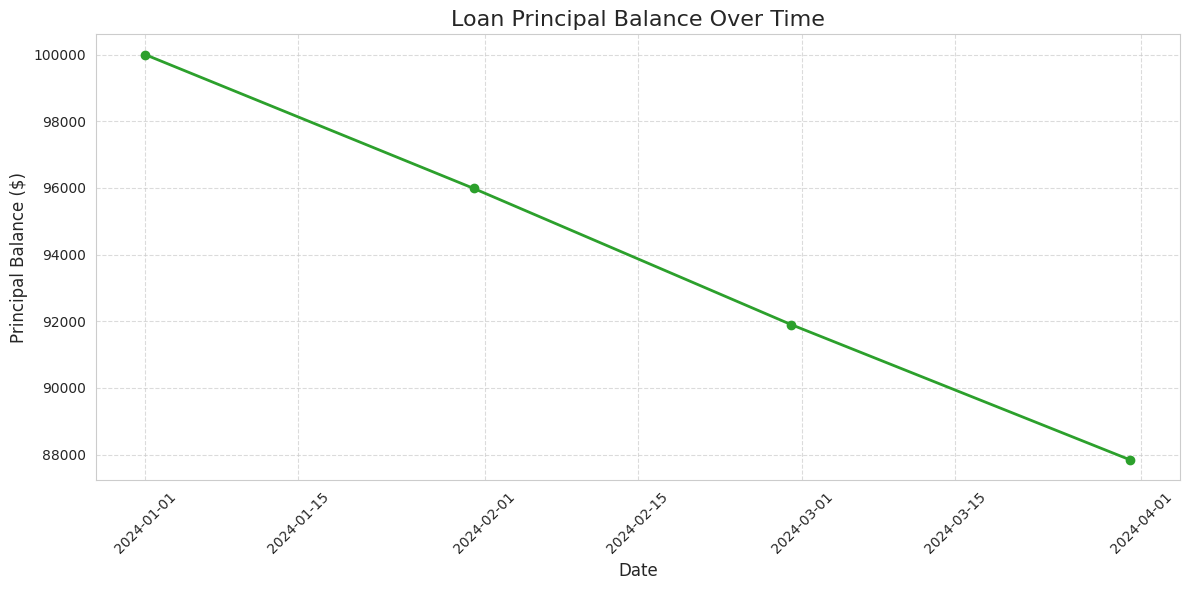

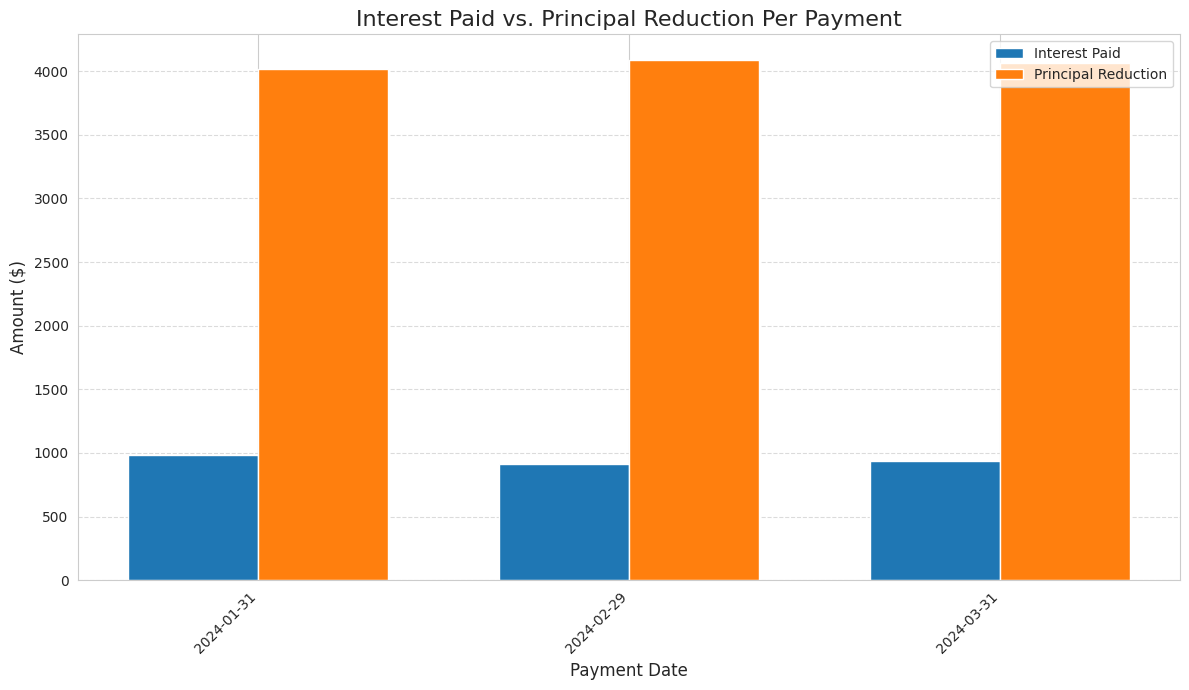

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Prepare data for plotting
plot_data = pd.DataFrame({
    'Date': payment_dates,
    'Principal Balance': principal_balances,
})

# Adjust payment dates for interest and principal reduction plots
payment_summary_data = pd.DataFrame({
    'Payment Date': payment_dates[1:], # Exclude start_date for payments
    'Interest Paid': interest_paid_per_period_list,
    'Principal Reduction': principal_reduction_per_period_list
})

# Set style for professional plots
sns.set_style("whitegrid")

# --- Plot 1: Principal Balance Over Time ---
plt.figure(figsize=(12, 6))
plt.plot(plot_data['Date'], plot_data['Principal Balance'], marker='o', linestyle='-', color='#2CA02C', linewidth=2) # Green for financial assets
plt.title('Loan Principal Balance Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Principal Balance ($)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# --- Plot 2: Interest Paid vs. Principal Reduction Per Payment ---
fig, ax = plt.subplots(figsize=(12, 7))

bar_width = 0.35
index = range(len(payment_summary_data['Payment Date']))

bar1 = ax.bar([i - bar_width/2 for i in index], payment_summary_data['Interest Paid'], bar_width, label='Interest Paid', color='#1f77b4') # Blue for banks/finance
bar2 = ax.bar([i + bar_width/2 for i in index], payment_summary_data['Principal Reduction'], bar_width, label='Principal Reduction', color='#ff7f0e') # Orange for contrast

ax.set_xlabel('Payment Date', fontsize=12)
ax.set_ylabel('Amount ($)', fontsize=12)
ax.set_title('Interest Paid vs. Principal Reduction Per Payment', fontsize=16)
ax.set_xticks(index)
ax.set_xticklabels([d.strftime('%Y-%m-%d') for d in payment_summary_data['Payment Date']], rotation=45, ha='right')
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Insights & Technical Learnings

### Key Results:
The audit reveals that after three payments of $5,000 each, the loan's principal balance stands at **$87,838.10**. Over this 90-day period, the total interest paid by the borrower is **$2,838.10**. This calculation rigorously accounts for the leap year 2024 and irregular payment period lengths, demonstrating the precise financial impact of 'calendar math'.
___
### Technical Learnings:
This task vividly highlights the limitations and potential **hallucinations of Large Language Models (LLMs)** when dealing with nuanced numerical and temporal data, specifically 'calendar math'. A simple amortization schedule prompt to an LLM would likely ignore the leap day (February 29, 2024) or assume standardized 30-day months, leading to an inaccurate ending balance and total interest. The manual, period-by-period calculation, though more laborious, ensures precision by directly integrating actual day counts, including the leap day. This contrasts sharply with an LLM's tendency to generalize or simplify, which is a critical flaw in high-stakes financial applications. The exercise reinforces that while LLMs are powerful for text generation and summarization, they are not reliable for precise, rule-based numerical calculations without external tooling or specialized, robust prompting.
___
### Practical Application:
This scenario has direct applications in **Fintech and AI auditing**. Financial institutions, especially those dealing with complex loan products, must ensure absolute accuracy in interest accrual and payment allocation. Reliance on AI models for such tasks requires a robust verification framework, often involving traditional algorithmic checks as demonstrated here. For developers building AI systems for finance, this underscores the importance of:
1.  **Hybrid AI Approaches**: Combining LLMs for qualitative analysis or user interaction with deterministic algorithms (like the one implemented) for quantitative accuracy.
2.  **Edge Case Testing**: Specifically designing test cases for irregular dates (leap years, weekends, holidays) to validate AI financial models.
3.  **Explainability**: The need for transparent, step-by-step calculations, rather than opaque AI outputs, to build trust and meet regulatory requirements in financial services. This audit provides an auditable, transparent record of the loan's status, which is crucial for dispute resolution and regulatory compliance.